In [ ]:
# This dataset has funding information of the Indian startups from January 2015 to August 2017.

# Feature Details:
# SNo - Serial number.
# Date - Date of funding in format DD/MM/YYYY.
# StartupName - Name of the startup which got funded.
# IndustryVertical - Industry to which the startup belongs.
# SubVertical - Sub-category of the industry type.
# CityLocation - City which the startup is based out of.
# InvestorsName - Name of the investors involved in the funding round.
# InvestmentType - Either Private Equity or Seed Funding.
# AmountInUSD - Funding Amount in USD.
# Remarks - Other information, if any.


# Find out what type of startups are getting funded in the last few years?
# Who are the important investors?
# What are the hot fields that get a lot of funding these days?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv("startup_funding.csv")

In [25]:
df.head()

,SNo,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
0,0,01/08/2017,TouchKin,Technology,Predictive Care Platform,Bangalore,Kae Capital,Private Equity,"1,300,000",NaN
1,1,02/08/2017,Ethinos,Technology,Digital Marketing Agency,Mumbai,Triton Investment Advisors,Private Equity,NaN,NaN
2,2,02/08/2017,Leverage Edu,Consumer Internet,Online platform for Higher Education Services,New Delhi,"Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...",Seed Funding,NaN,NaN
3,3,02/08/2017,Zepo,Consumer Internet,DIY Ecommerce platform,Mumbai,"Kunal Shah, LetsVenture, Anupam Mittal, Hetal ...",Seed Funding,"500,000",NaN
4,4,02/08/2017,Click2Clinic,Consumer Internet,healthcare service aggregator,Hyderabad,"Narottam Thudi, Shireesh Palle",Seed Funding,"850,000",NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SNo               2372 non-null   int64 
 1   Date              2372 non-null   object
 2   StartupName       2372 non-null   object
 3   IndustryVertical  2201 non-null   object
 4   SubVertical       1436 non-null   object
 5   CityLocation      2193 non-null   object
 6   InvestorsName     2364 non-null   object
 7   InvestmentType    2371 non-null   object
 8   AmountInUSD       1525 non-null   object
 9   Remarks           419 non-null    object
dtypes: int64(1), object(9)
memory usage: 185.4+ KB


In [7]:
df[df.dtypes[df.dtypes=='object'].index][:5]

,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
0,01/08/2017,TouchKin,Technology,Predictive Care Platform,Bangalore,Kae Capital,Private Equity,"1,300,000",NaN
1,02/08/2017,Ethinos,Technology,Digital Marketing Agency,Mumbai,Triton Investment Advisors,Private Equity,NaN,NaN
2,02/08/2017,Leverage Edu,Consumer Internet,Online platform for Higher Education Services,New Delhi,"Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...",Seed Funding,NaN,NaN
3,02/08/2017,Zepo,Consumer Internet,DIY Ecommerce platform,Mumbai,"Kunal Shah, LetsVenture, Anupam Mittal, Hetal ...",Seed Funding,"500,000",NaN
4,02/08/2017,Click2Clinic,Consumer Internet,healthcare service aggregator,Hyderabad,"Narottam Thudi, Shireesh Palle",Seed Funding,"850,000",NaN


In [8]:
df.select_dtypes(include='object')[:5]  ## There are two ways to get data a/c to dtypes

,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
0,01/08/2017,TouchKin,Technology,Predictive Care Platform,Bangalore,Kae Capital,Private Equity,"1,300,000",NaN
1,02/08/2017,Ethinos,Technology,Digital Marketing Agency,Mumbai,Triton Investment Advisors,Private Equity,NaN,NaN
2,02/08/2017,Leverage Edu,Consumer Internet,Online platform for Higher Education Services,New Delhi,"Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...",Seed Funding,NaN,NaN
3,02/08/2017,Zepo,Consumer Internet,DIY Ecommerce platform,Mumbai,"Kunal Shah, LetsVenture, Anupam Mittal, Hetal ...",Seed Funding,"500,000",NaN
4,02/08/2017,Click2Clinic,Consumer Internet,healthcare service aggregator,Hyderabad,"Narottam Thudi, Shireesh Palle",Seed Funding,"850,000",NaN


In [9]:
df[df.dtypes[df.dtypes=='object'].index].describe()

,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
count,2372,2372,2201,1436,2193,2364,2371,1525,419
unique,701,2001,743,1364,71,1885,7,329,69
top,02/02/2015,Swiggy,Consumer Internet,Online Pharmacy,Bangalore,Undisclosed Investors,Seed Funding,"1,000,000",Series A
freq,11,7,772,9,627,33,1271,130,177


In [10]:
df.describe

<bound method NDFrame.describe of        SNo        Date       StartupName   IndustryVertical  \
0        0  01/08/2017          TouchKin         Technology   
1        1  02/08/2017           Ethinos         Technology   
2        2  02/08/2017      Leverage Edu  Consumer Internet   
3        3  02/08/2017              Zepo  Consumer Internet   
4        4  02/08/2017      Click2Clinic  Consumer Internet   
...    ...         ...               ...                ...   
2367  2367  29/01/2015        Printvenue                NaN   
2368  2368  29/01/2015          Graphene                NaN   
2369  2369  30/01/2015    Mad Street Den                NaN   
2370  2370  30/01/2015         Simplotel                NaN   
2371  2371  31/01/2015  couponmachine.in                NaN   

                                        SubVertical CityLocation  \
0                          Predictive Care Platform    Bangalore   
1                          Digital Marketing Agency       Mumbai   
2    

In [11]:
df.isnull().sum()

SNo                    0
Date                   0
StartupName            0
IndustryVertical     171
SubVertical          936
CityLocation         179
InvestorsName          8
InvestmentType         1
AmountInUSD          847
Remarks             1953
dtype: int64

In [27]:
# Find out what type of startups are getting funded in the last few years?


# so first we seprate the year from the data column and save in the new column year.
## 1. First we change the date type object ot date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce') # (errors='coerce' will turn invalid entries into NaT instead of crashing.)
df['Date'].dtype

dtype('<M8[ns]')

In [28]:
## Seprate the year and Date from Date column
df['Year']=df['Date'].dt.year 

In [29]:
df['month']=df['Date'].dt.month

In [30]:
df=df.sort_values('Year',ascending=False)

In [53]:
df[['IndustryVertical','Year']][:5]

,IndustryVertical,Year
0,Technology,2017
292,Consumer Internet,2017
303,Technology,2017
302,Consumer Internet,2017
301,Technology,2017


In [43]:
df=df.dropna(subset=['Year']) ## Delete the null values

C:\Users\rupes\AppData\Local\Temp\ipykernel_6396\3973423949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


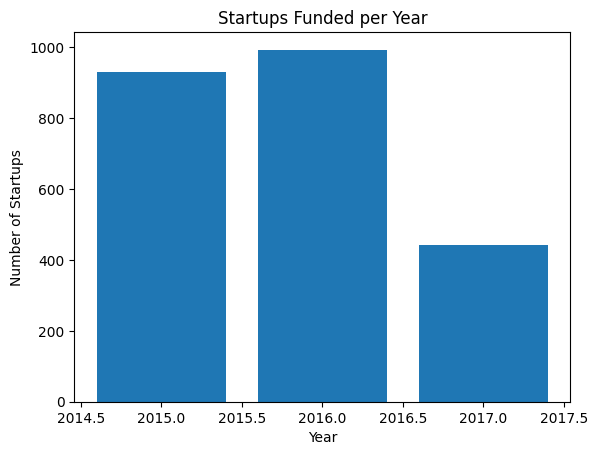

In [61]:
df['Year'] = df['Year'].astype(int)
year_counts = df['Year'].value_counts().sort_index()

plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of Startups")
plt.title("Startups Funded per Year")
plt.show()
